In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from datetime import datetime

def time_to_seconds(t):
    dt = datetime.strptime(t, "%H:%M:%S.%f")
    return dt.hour * 3600 + dt.minute * 60 + dt.second + dt.microsecond / 1e6

vectorized_time_to_seconds = np.vectorize(time_to_seconds)

In [3]:
file_dir = "../simulation/measurements/files"

particle_counts = [1500, 3500, 7500, 17000, 37000, 85000, 190000, 420000, 950000, 2200000, 5000000]
modes = ["computeShaders", "sequential", "parallel"]

In [4]:
# 06-12 18:24:49.724  7352  7409 I Timer   : Elapsed time: 17.248888 ms
# 06-12 18:24:49.738  7352  7409 I GpuTimerCompute: Elapsed time: 0.000313 ms
# 06-12 18:24:49.741  7352  7409 I GpuTimerRender: Elapsed time: 1.439792 ms
# 06-12 18:24:49.759  7352  7409 I CpuTimer: Elapsed time: 23.402828 ms
# 06-13 13:39:05.513 21531 21562 I CpuTimerCompute: Elapsed time: 18.706000 ms
# 06-12 18:24:49.941  7352  7436 I CpuTimerLoader: Elapsed time: 1284.709000 ms

pd_cs = pd.DataFrame(columns=["particle_count",
                            "avg_time", "avg_time_err",
                            "avg_time_per_particle", "avg_time_per_particle_err",
                            "avg_time_compute", "avg_time_compute_err",
                            "avg_time_per_particle_compute", "avg_time_per_particle_compute_err",
                            "avg_time_compute_cpu", "avg_time_compute_cpu_err",
                            "avg_time_per_particle_compute_cpu", "avg_time_per_particle_compute_cpu_err",
                            "avg_time_render", "avg_time_render_err",
                            "avg_time_per_particle_render", "avg_time_per_particle_render_err",
                            "avg_time_cpu", "avg_time_cpu_err",
                            "avg_time_per_particle_cpu", "avg_time_per_particle_cpu_err",
                            "avg_time_loader", "avg_time_loader_err",
                            ])

pd_seq = pd.DataFrame(columns=["particle_count",
                            "avg_time", "avg_time_err",
                            "avg_time_per_particle", "avg_time_per_particle_err",
                            "avg_time_compute", "avg_time_compute_err",
                            "avg_time_per_particle_compute", "avg_time_per_particle_compute_err",
                            "avg_time_compute_cpu", "avg_time_compute_cpu_err",
                            "avg_time_per_particle_compute_cpu", "avg_time_per_particle_compute_cpu_err",
                            "avg_time_render", "avg_time_render_err",
                            "avg_time_per_particle_render", "avg_time_per_particle_render_err",
                            "avg_time_cpu", "avg_time_cpu_err",
                            "avg_time_per_particle_cpu", "avg_time_per_particle_cpu_err",
                            "avg_time_loader", "avg_time_loader_err",
                            ])

pd_par = pd.DataFrame(columns=["particle_count",
                            "avg_time", "avg_time_err",
                            "avg_time_per_particle", "avg_time_per_particle_err",
                            "avg_time_compute", "avg_time_compute_err",
                            "avg_time_per_particle_compute", "avg_time_per_particle_compute_err",
                            "avg_time_compute_cpu", "avg_time_compute_cpu_err",
                            "avg_time_per_particle_compute_cpu", "avg_time_per_particle_compute_cpu_err",
                            "avg_time_render", "avg_time_render_err",
                            "avg_time_per_particle_render", "avg_time_per_particle_render_err",
                            "avg_time_cpu", "avg_time_cpu_err",
                            "avg_time_per_particle_cpu", "avg_time_per_particle_cpu_err",
                            "avg_time_loader", "avg_time_loader_err",
                            ])

pd_cs["particle_count"] = particle_counts
pd_seq["particle_count"] = particle_counts
pd_par["particle_count"] = particle_counts

thousands = []
thousands_time_stamps = []
hundred_thousands = []
hundred_thousands_time_stamps = []
millions = []
millions_time_stamps = []

for mode in modes:
    avg_times = []
    avg_times_err = []
    avg_times_per_particle = []
    avg_times_per_particle_err = []

    avg_times_compute = []
    avg_times_compute_err = []
    avg_times_per_particle_compute = []
    avg_times_per_particle_compute_err = []

    avg_times_compute_cpu = []
    avg_times_compute_cpu_err = []
    avg_times_per_particle_compute_cpu = []
    avg_times_per_particle_compute_cpu_err = []

    avg_times_render = []
    avg_times_render_err = []
    avg_times_per_particle_render = []
    avg_times_per_particle_render_err = []

    avg_times_cpu = []
    avg_times_cpu_err = []
    avg_times_per_particle_cpu = []
    avg_times_per_particle_cpu_err = []

    avg_times_loader = []
    avg_times_loader_err = []
    avg_times_per_particle_loader = []
    avg_times_per_particle_loader_err = []

    for count in particle_counts:
        file = open(f"{file_dir}/logs_{count}_{mode}5.txt", "r").read()

        all_times = []
        all_times_compute = []
        all_times_compute_cpu = []
        all_times_render = []
        all_times_cpu = []
        all_times_loader = []
        all_time_stamps = []
        for line in file.split("\n"):
            if "CpuTimerLoader" in line and count < 500000:  # For larger particle counts, not enough loader data is measured
                if "ms" in line:
                    time = float(line.split("Elapsed time: ")[1].split(" ")[0])
                    all_times_loader.append(time)

            elif "CpuTimerCompute" in line:
                if "ms" in line:
                    time = float(line.split("Elapsed time: ")[1].split(" ")[0])
                    all_times_compute_cpu.append(time)

            elif "CpuTimer" in line:
                if "ms" in line:
                    time = float(line.split("Elapsed time: ")[1].split(" ")[0])
                    if not (time > 2*np.mean(all_times_cpu)):  # Remove values affected by loader time
                        all_times_cpu.append(time)

            elif "GpuTimerRender" in line:
                if "ms" in line:
                    time = float(line.split("Elapsed time: ")[1].split(" ")[0])
                    all_times_render.append(time)

            elif "GpuTimerCompute" in line:
                if "ms" in line:
                    time = float(line.split("Elapsed time: ")[1].split(" ")[0])
                    all_times_compute.append(time)

            else:
                # "Timer" in line
                if "ms" in line:
                    time = float(line.split("Elapsed time: ")[1].split(" ")[0])
                    time_stamp = line.split(" ")[1]
                    all_times.append(time)
                    all_time_stamps.append(time_stamp)

        if count == 1500:
            thousands.append(all_times)
            thousands_time_stamps.append(all_time_stamps)
        if count == 190000:
            hundred_thousands.append(all_times)
            hundred_thousands_time_stamps.append(all_time_stamps)
        if count == 950000:
            millions.append(all_times)
            millions_time_stamps.append(all_time_stamps)

        ####################################################### Means
        avg_time = np.mean(all_times)
        avg_time_err = np.std(all_times)
        avg_time_per_particle = avg_time / count
        avg_time_per_particle_err = avg_time_err / count

        avg_time_loader = np.mean(all_times_loader)
        avg_time_loader_err = np.std(all_times_loader)
        avg_time_per_particle_loader = avg_time_loader / count
        avg_time_per_particle_loader_err = avg_time_loader_err / count

        avg_time_cpu = np.mean(all_times_cpu)
        avg_time_cpu_err = np.std(all_times_cpu)
        avg_time_per_particle_cpu = avg_time_cpu / count
        avg_time_per_particle_cpu_err = avg_time_cpu_err / count

        avg_time_render = np.mean(all_times_render)
        avg_time_render_err = np.std(all_times_render)
        avg_time_per_particle_render = avg_time_render / count
        avg_time_per_particle_render_err = avg_time_render_err / count

        avg_time_compute = np.mean(all_times_compute)
        avg_time_compute_err = np.std(all_times_compute)
        avg_time_per_particle_compute = avg_time_compute / count
        avg_time_per_particle_compute_err = avg_time_compute_err / count

        # Here we first remove anything aboce 2*mean(all_times_cpu) to remove the loader time
        all_times_compute_cpu = [time for time in all_times_compute_cpu if time < 2*np.mean(all_times_cpu)]
        avg_time_compute_cpu = np.mean(all_times_compute_cpu)
        avg_time_compute_cpu_err = np.std(all_times_compute_cpu)
        avg_time_per_particle_compute_cpu = avg_time_compute_cpu / count
        avg_time_per_particle_compute_cpu_err = avg_time_compute_cpu_err / count

        ####################################################### Appends
        avg_times_loader.append(avg_time_loader)
        avg_times_loader_err.append(avg_time_loader_err)
        avg_times_per_particle_loader.append(avg_time_per_particle_loader)
        avg_times_per_particle_loader_err.append(avg_time_per_particle_loader_err)

        avg_times_cpu.append(avg_time_cpu)
        avg_times_cpu_err.append(avg_time_cpu_err)
        avg_times_per_particle_cpu.append(avg_time_per_particle_cpu)
        avg_times_per_particle_cpu_err.append(avg_time_per_particle_cpu_err)

        avg_times_render.append(avg_time_render)
        avg_times_render_err.append(avg_time_render_err)
        avg_times_per_particle_render.append(avg_time_per_particle_render)
        avg_times_per_particle_render_err.append(avg_time_per_particle_render_err)

        avg_times_compute.append(avg_time_compute)
        avg_times_compute_err.append(avg_time_compute_err)
        avg_times_per_particle_compute.append(avg_time_per_particle_compute)
        avg_times_per_particle_compute_err.append(avg_time_per_particle_compute_err)

        avg_times.append(avg_time)
        avg_times_err.append(avg_time_err)
        avg_times_per_particle.append(avg_time_per_particle)
        avg_times_per_particle_err.append(avg_time_per_particle_err)

        avg_times_compute_cpu.append(avg_time_compute_cpu)
        avg_times_compute_cpu_err.append(avg_time_compute_cpu_err)
        avg_times_per_particle_compute_cpu.append(avg_time_per_particle_compute_cpu)
        avg_times_per_particle_compute_cpu_err.append(avg_time_per_particle_compute_cpu_err)
        #######################################################

    if mode == "computeShaders":
        pd_cs["avg_time"] = avg_times
        pd_cs["avg_time_err"] = avg_times_err
        pd_cs["avg_time_per_particle"] = avg_times_per_particle
        pd_cs["avg_time_per_particle_err"] = avg_times_per_particle_err

        pd_cs["avg_time_loader"] = avg_times_loader
        pd_cs["avg_time_loader_err"] = avg_times_loader_err
        pd_cs["avg_time_per_particle_loader"] = avg_times_per_particle_loader
        pd_cs["avg_time_per_particle_loader_err"] = avg_times_per_particle_loader_err

        pd_cs["avg_time_cpu"] = avg_times_cpu
        pd_cs["avg_time_cpu_err"] = avg_times_cpu_err
        pd_cs["avg_time_per_particle_cpu"] = avg_times_per_particle_cpu
        pd_cs["avg_time_per_particle_cpu_err"] = avg_times_per_particle_cpu_err

        pd_cs["avg_time_render"] = avg_times_render
        pd_cs["avg_time_render_err"] = avg_times_render_err
        pd_cs["avg_time_per_particle_render"] = avg_times_per_particle_render
        pd_cs["avg_time_per_particle_render_err"] = avg_times_per_particle_render_err

        pd_cs["avg_time_compute"] = avg_times_compute
        pd_cs["avg_time_compute_err"] = avg_times_compute_err
        pd_cs["avg_time_per_particle_compute"] = avg_times_per_particle_compute
        pd_cs["avg_time_per_particle_compute_err"] = avg_times_per_particle_compute_err

        pd_cs["avg_time_compute_cpu"] = avg_times_compute_cpu
        pd_cs["avg_time_compute_cpu_err"] = avg_times_compute_cpu_err
        pd_cs["avg_time_per_particle_compute_cpu"] = avg_times_per_particle_compute_cpu
        pd_cs["avg_time_per_particle_compute_cpu_err"] = avg_times_per_particle_compute_cpu_err

    elif mode == "sequential":
        pd_seq["avg_time"] = avg_times
        pd_seq["avg_time_err"] = avg_times_err
        pd_seq["avg_time_per_particle"] = avg_times_per_particle
        pd_seq["avg_time_per_particle_err"] = avg_times_per_particle_err

        pd_seq["avg_time_loader"] = avg_times_loader
        pd_seq["avg_time_loader_err"] = avg_times_loader_err
        pd_seq["avg_time_per_particle_loader"] = avg_times_per_particle_loader
        pd_seq["avg_time_per_particle_loader_err"] = avg_times_per_particle_loader_err

        pd_seq["avg_time_cpu"] = avg_times_cpu
        pd_seq["avg_time_cpu_err"] = avg_times_cpu_err
        pd_seq["avg_time_per_particle_cpu"] = avg_times_per_particle_cpu
        pd_seq["avg_time_per_particle_cpu_err"] = avg_times_per_particle_cpu_err

        pd_seq["avg_time_render"] = avg_times_render
        pd_seq["avg_time_render_err"] = avg_times_render_err
        pd_seq["avg_time_per_particle_render"] = avg_times_per_particle_render
        pd_seq["avg_time_per_particle_render_err"] = avg_times_per_particle_render_err

        pd_seq["avg_time_compute"] = avg_times_compute
        pd_seq["avg_time_compute_err"] = avg_times_compute_err
        pd_seq["avg_time_per_particle_compute"] = avg_times_per_particle_compute
        pd_seq["avg_time_per_particle_compute_err"] = avg_times_per_particle_compute_err

        pd_seq["avg_time_compute_cpu"] = avg_times_compute_cpu
        pd_seq["avg_time_compute_cpu_err"] = avg_times_compute_cpu_err
        pd_seq["avg_time_per_particle_compute_cpu"] = avg_times_per_particle_compute_cpu
        pd_seq["avg_time_per_particle_compute_cpu_err"] = avg_times_per_particle_compute_cpu_err

    elif mode == "parallel":
        pd_par["avg_time"] = avg_times
        pd_par["avg_time_err"] = avg_times_err
        pd_par["avg_time_per_particle"] = avg_times_per_particle
        pd_par["avg_time_per_particle_err"] = avg_times_per_particle_err

        pd_par["avg_time_loader"] = avg_times_loader
        pd_par["avg_time_loader_err"] = avg_times_loader_err
        pd_par["avg_time_per_particle_loader"] = avg_times_per_particle_loader
        pd_par["avg_time_per_particle_loader_err"] = avg_times_per_particle_loader_err

        pd_par["avg_time_cpu"] = avg_times_cpu
        pd_par["avg_time_cpu_err"] = avg_times_cpu_err
        pd_par["avg_time_per_particle_cpu"] = avg_times_per_particle_cpu
        pd_par["avg_time_per_particle_cpu_err"] = avg_times_per_particle_cpu_err

        pd_par["avg_time_render"] = avg_times_render
        pd_par["avg_time_render_err"] = avg_times_render_err
        pd_par["avg_time_per_particle_render"] = avg_times_per_particle_render
        pd_par["avg_time_per_particle_render_err"] = avg_times_per_particle_render_err

        pd_par["avg_time_compute"] = avg_times_compute
        pd_par["avg_time_compute_err"] = avg_times_compute_err
        pd_par["avg_time_per_particle_compute"] = avg_times_per_particle_compute
        pd_par["avg_time_per_particle_compute_err"] = avg_times_per_particle_compute_err
        
        pd_par["avg_time_compute_cpu"] = avg_times_compute_cpu
        pd_par["avg_time_compute_cpu_err"] = avg_times_compute_cpu_err
        pd_par["avg_time_per_particle_compute_cpu"] = avg_times_per_particle_compute_cpu
        pd_par["avg_time_per_particle_compute_cpu_err"] = avg_times_per_particle_compute_cpu_err

/home/martin/repos/Lagrangian-fluid-simulation-for-Android/utils/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/martin/repos/Lagrangian-fluid-simulation-for-Android/utils/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/martin/repos/Lagrangian-fluid-simulation-for-Android/utils/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/martin/repos/Lagrangian-fluid-simulation-for-Android/utils/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/martin/repos/Lagrangian-fluid-simulation-for-Android/utils/.venv/lib/pytho

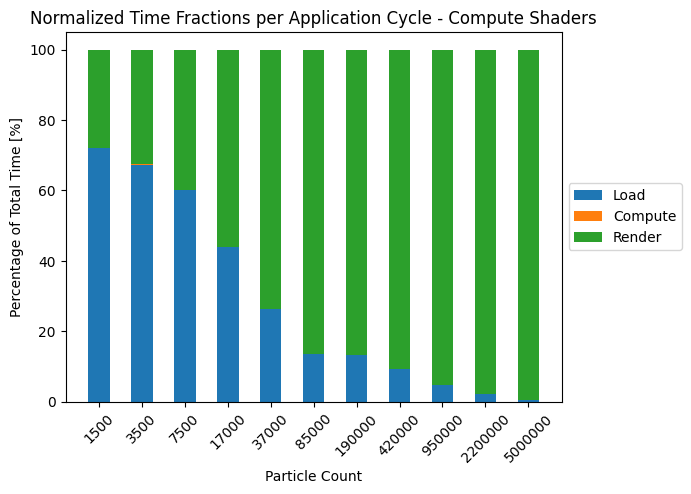

In [5]:
# Stacked bars compute shaders
chunk = 11
species = [str(x) for x in particle_counts[0:chunk]]
weight_counts = {
    "Load": np.array(pd_cs["avg_time_cpu"])[0:chunk] / 2,
    "Compute": np.array(pd_cs["avg_time_compute"])[0:chunk],
    "Render": np.array(pd_cs["avg_time_render"])[0:chunk], 
}
total_time = sum(weight_counts.values())
normalized_weights = {key: (weight / total_time) * 100 for key, weight in weight_counts.items()}

width = 0.5

fig, ax = plt.subplots()
bottom = np.zeros(len(species))

for key, weight in normalized_weights.items():
    ax.bar(species, weight, width=width, bottom=bottom, label=key)
    bottom += weight

ax.set_ylabel('Percentage of Total Time [%]')
ax.set_xlabel('Particle Count')

ax.set_title('Normalized Time Fractions per Application Cycle - Compute Shaders')
plt.xticks(rotation=45)

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

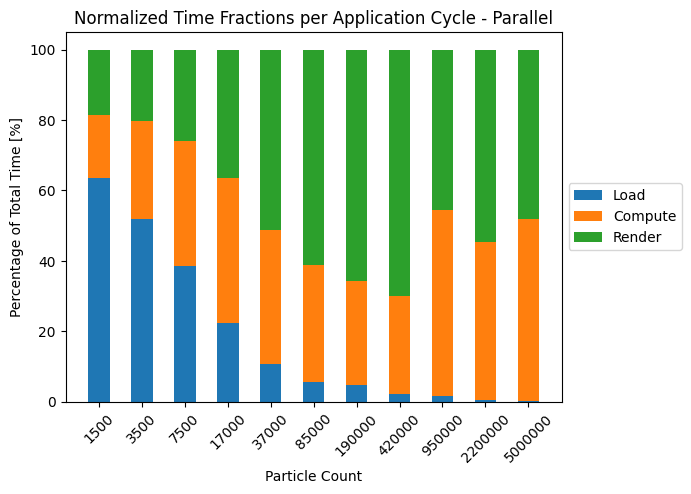

In [6]:
# Stacked bars parallel
chunk = 11
species = [str(x) for x in particle_counts[0:chunk]]
weight_counts = {
    "Load": np.array(pd_par["avg_time_cpu"] - pd_par["avg_time_compute_cpu"])[0:chunk] / 2,
    "Compute": np.array(pd_par["avg_time_compute_cpu"])[0:chunk]/8,
    "Render": np.array(pd_par["avg_time_render"])[0:chunk], 
}
total_time = sum(weight_counts.values())
normalized_weights = {key: (weight / total_time) * 100 for key, weight in weight_counts.items()}

width = 0.5

fig, ax = plt.subplots()
bottom = np.zeros(len(species))

for key, weight in normalized_weights.items():
    ax.bar(species, weight, width=width, bottom=bottom, label=key)
    bottom += weight

ax.set_ylabel('Percentage of Total Time [%]')
ax.set_xlabel('Particle Count')

ax.set_title('Normalized Time Fractions per Application Cycle - Parallel')
plt.xticks(rotation=45)

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

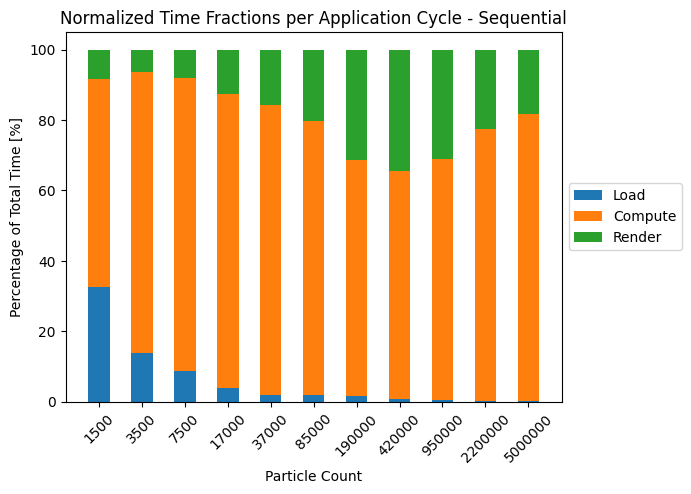

In [7]:
# Stacked bars sequential
chunk = 11
species = [str(x) for x in particle_counts[0:chunk]]
weight_counts = {
    "Load": np.array(pd_seq["avg_time_cpu"] - pd_seq["avg_time_compute_cpu"])[0:chunk] / 2,
    "Compute": np.array(pd_seq["avg_time_compute_cpu"])[0:chunk],
    "Render": np.array(pd_seq["avg_time_render"])[0:chunk], 
}
total_time = sum(weight_counts.values())
normalized_weights = {key: (weight / total_time) * 100 for key, weight in weight_counts.items()}

width = 0.5

fig, ax = plt.subplots()
bottom = np.zeros(len(species))

for key, weight in normalized_weights.items():
    ax.bar(species, weight, width=width, bottom=bottom, label=key)
    bottom += weight

ax.set_ylabel('Percentage of Total Time [%]')
ax.set_xlabel('Particle Count')
ax.set_title('Normalized Time Fractions per Application Cycle - Sequential')
plt.xticks(rotation=45)

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

/tmp/ipykernel_16584/1197914010.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels(species, rotation=45)
/tmp/ipykernel_16584/1197914010.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1].set_xticklabels(species, rotation=45)
/tmp/ipykernel_16584/1197914010.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[2].set_xticklabels(species, rotation=45)


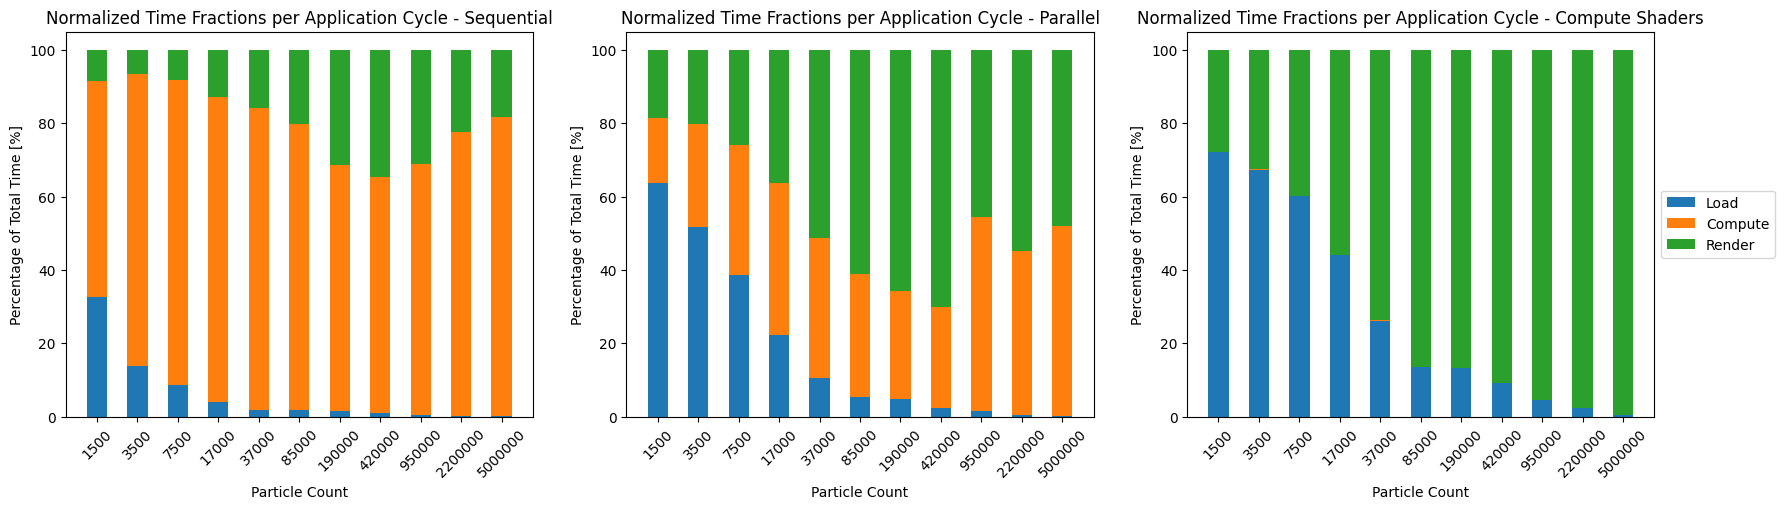

In [8]:
# All three side by side
fig, axs = plt.subplots(1, 3, figsize=(20.5, 5))
chunk = 11
species = [str(x) for x in particle_counts[0:chunk]]
width = 0.5

# Sequential
weight_counts = {
    "Load": np.array(pd_seq["avg_time_cpu"] - pd_seq["avg_time_compute_cpu"])[0:chunk] / 2,
    "Compute": np.array(pd_seq["avg_time_compute_cpu"])[0:chunk],
    "Render": np.array(pd_seq["avg_time_render"])[0:chunk], 
}
total_time = sum(weight_counts.values())
normalized_weights = {key: (weight / total_time) * 100 for key, weight in weight_counts.items()}

bottom = np.zeros(len(species))
for key, weight in normalized_weights.items():
    axs[0].bar(species, weight, width=width, bottom=bottom, label=key)
    bottom += weight

axs[0].set_ylabel('Percentage of Total Time [%]')
axs[0].set_xlabel('Particle Count')
axs[0].set_title('Normalized Time Fractions per Application Cycle - Sequential')
axs[0].set_xticklabels(species, rotation=45)

# Parallel
weight_counts = {
    "Load": np.array(pd_par["avg_time_cpu"] - pd_par["avg_time_compute_cpu"])[0:chunk] / 2,
    "Compute": np.array(pd_par["avg_time_compute_cpu"])[0:chunk]/8,
    "Render": np.array(pd_par["avg_time_render"])[0:chunk], 
}
total_time = sum(weight_counts.values())
normalized_weights = {key: (weight / total_time) * 100 for key, weight in weight_counts.items()}

bottom = np.zeros(len(species))
for key, weight in normalized_weights.items():
    axs[1].bar(species, weight, width=width, bottom=bottom, label=key)
    bottom += weight

axs[1].set_ylabel('Percentage of Total Time [%]')
axs[1].set_xlabel('Particle Count')
axs[1].set_title('Normalized Time Fractions per Application Cycle - Parallel')
axs[1].set_xticklabels(species, rotation=45)

# Compute shaders
weight_counts = {
    "Load": np.array(pd_cs["avg_time_cpu"])[0:chunk] / 2,
    "Compute": np.array(pd_cs["avg_time_compute"])[0:chunk],
    "Render": np.array(pd_cs["avg_time_render"])[0:chunk], 
}
total_time = sum(weight_counts.values())
normalized_weights = {key: (weight / total_time) * 100 for key, weight in weight_counts.items()}


bottom = np.zeros(len(species))
for key, weight in normalized_weights.items():
    axs[2].bar(species, weight, width=width, bottom=bottom, label=key)
    bottom += weight

axs[2].set_ylabel('Percentage of Total Time [%]')
axs[2].set_xlabel('Particle Count')
axs[2].set_title('Normalized Time Fractions per Application Cycle - Compute Shaders')
axs[2].set_xticklabels(species, rotation=45)


plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

# Export data to CSV
dest_dir = "processed_data"
pd_seq.to_csv(f"{dest_dir}/hist_seq.csv", index=False)
pd_par.to_csv(f"{dest_dir}/hist_render_par.csv", index=False)
pd_cs.to_csv(f"{dest_dir}/hist_render_cs.csv", index=False)